# TA Session 17: Python: Logistic Regression, Naive Bayes classifiers, Support Vector Machines (SVM)

**See details about these models in [Lecture 9](https://canvas.harvard.edu/courses/164143/files/folder/Slides?preview=23689084) from October 28, 2025.**

**Comparison between models:**

  * [Logistic regression](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression)
     * Linear, discriminative model
     * Balanced performance and interpretability
  * [Naive Bayes](https://scikit-learn.org/stable/modules/naive_bayes.html)
     * Probabilistic, assumes word independence
     * Small datasets, fast baseline
  * [SVM](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)
     * Maximizes margin between classes
     * Larger datasets, stronger separation needed
  * Neural Networks
     * Nonlinear and deep feature interactions
     * Large-scale text datasets

**Import models libraries**

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes  import MultinomialNB
from sklearn.svm          import SVC

**Import other necessary libraries:**

  * `TfidfVectorizer` converts text into numerical features using TF-IDF weighting
  * `train_test_split` splits data into training and test sets
  * `accuracy_score` measures prediction accuracy

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection         import train_test_split
from sklearn.metrics                 import accuracy_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from IPython.display import display, HTML

## Training Dataset and its TF-IDF Vectorization

**See details about TF-IDF numerical representation of the text data in [Lecture 5](https://canvas.harvard.edu/courses/164143/files/folder/Slides?preview=23371328) from September 30, 2025.**

**Define sample documents: short sentences about cats or dogs.**



In [3]:
documents = [
"Cats purr gently and climb high trees. Chasing a mouse is fun for cats.",
"Independent creatures, cats enjoy solitude and love their nap time.",
"Dogs bark loudly at strangers and fetch sticks with enthusiasm.",
"Loyal dogs accompany humans on hikes and love to chase balls.",
"When the energetic dog spotted a squirrel, it barked energetically.",
"A purring cat climbed the bookshelf, watching over the room.",
"Regularly, dogs enjoy long walks, sniffing and exploring their environment.",
"Cats meow softly and purr when content, loving to stretch in the sun."
]

**Define corresponding numeric labels:**
  * `0` = cat-related
  * `1` = dog-related

These labels are the target variable for supervised learning.

In [4]:
labels = [0, 0, 1, 1, 1, 0, 1, 0]

**Randomly divide the documents and labels into training and testing sets**
  * `test_size=0.25` sets 25% for testing and 75% for training
  * `random_state` ensures reproducibility of results

In [5]:
docs_train , docs_test , y_train , y_test = train_test_split( documents, labels, test_size=0.25, random_state=1642 )

**Vectorize the training data: convert each text document into a TF-IDF weighted feature vector, representing the importance of words. This learns the vocabulary from training data and applies the transformation.**

In [6]:
vectorizer = TfidfVectorizer()
# vectorizer = TfidfVectorizer(stop_words='english') # This removes frequent English stop words (see below for details)
X_train = vectorizer.fit_transform( docs_train )

**Shape of the returned numeric matrix**

In [7]:
n_docs_train = X_train.shape[0]
n_unique_words = X_train.shape[1]
display(HTML(f"<p><b>Number of training documents: {n_docs_train:,}</b></p>"))
display(HTML(f"<p><b>Number of unique words in the corpus: {n_unique_words:,}</b></p>"))

**The learned vocabulary: mapping words to feature indices:**

In [8]:
print(vectorizer.vocabulary_)

{'loyal': 30, 'dogs': 13, 'accompany': 0, 'humans': 24, 'on': 33, 'hikes': 23, 'and': 1, 'love': 29, 'to': 46, 'chase': 7, 'balls': 2, 'cats': 6, 'purr': 35, 'gently': 21, 'climb': 9, 'high': 22, 'trees': 47, 'chasing': 8, 'mouse': 31, 'is': 26, 'fun': 20, 'for': 19, 'independent': 25, 'creatures': 11, 'enjoy': 16, 'solitude': 40, 'their': 44, 'nap': 32, 'time': 45, 'when': 50, 'the': 43, 'energetic': 14, 'dog': 12, 'spotted': 41, 'squirrel': 42, 'it': 27, 'barked': 3, 'energetically': 15, 'purring': 36, 'cat': 5, 'climbed': 10, 'bookshelf': 4, 'watching': 49, 'over': 34, 'room': 38, 'regularly': 37, 'long': 28, 'walks': 48, 'sniffing': 39, 'exploring': 18, 'environment': 17}


**Feature names: sorted list of words**

In [9]:
print(vectorizer.get_feature_names_out())

['accompany' 'and' 'balls' 'barked' 'bookshelf' 'cat' 'cats' 'chase'
 'chasing' 'climb' 'climbed' 'creatures' 'dog' 'dogs' 'energetic'
 'energetically' 'enjoy' 'environment' 'exploring' 'for' 'fun' 'gently'
 'high' 'hikes' 'humans' 'independent' 'is' 'it' 'long' 'love' 'loyal'
 'mouse' 'nap' 'on' 'over' 'purr' 'purring' 'regularly' 'room' 'sniffing'
 'solitude' 'spotted' 'squirrel' 'the' 'their' 'time' 'to' 'trees' 'walks'
 'watching' 'when']


**Show the TF-IDF matrix: each value shows how important that word is for that document**

In [10]:
pd.DataFrame(X_train.toarray(), columns=vectorizer.get_feature_names_out())

,accompany,and,balls,barked,bookshelf,cat,cats,chase,chasing,climb,...,spotted,squirrel,the,their,time,to,trees,walks,watching,when
0,0.321134,0.190515,0.321134,0.00000,0.000000,0.000000,0.000000,0.321134,0.000000,0.000000,...,0.00000,0.00000,0.000000,0.000000,0.000000,0.321134,0.000000,0.000000,0.000000,0.00000
1,0.000000,0.164278,0.000000,0.00000,0.000000,0.000000,0.454135,0.000000,0.276907,0.276907,...,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.276907,0.000000,0.000000,0.00000
2,0.000000,0.209205,0.000000,0.00000,0.000000,0.000000,0.289167,0.000000,0.000000,0.000000,...,0.00000,0.00000,0.000000,0.289167,0.352637,0.000000,0.000000,0.000000,0.000000,0.00000
3,0.000000,0.000000,0.000000,0.33957,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.33957,0.33957,0.278453,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.33957
4,0.000000,0.000000,0.000000,0.00000,0.321251,0.321251,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.00000,0.526861,0.000000,0.000000,0.000000,0.000000,0.000000,0.321251,0.00000
5,0.000000,0.205070,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.00000,0.000000,0.283452,0.000000,0.000000,0.000000,0.345667,0.000000,0.00000


**Show top 5 most important words per document**

Note: frequent English words are still in the vocabularly. If we want TF-IDF to ignore such general English words, then we need to tell it explicitly to remove stop words with

`vectorizer = TfidfVectorizer(stop_words='english')`

This uses scikit-learn's built-in English stopword list, automatically removing words like: 'the', 'a', 'to', 'and', 'of', 'in', 'is', 'for', etc.

In [11]:
feature_names = vectorizer.get_feature_names_out()
for i, doc in enumerate(X_train.toarray()):
    top_indices = doc.argsort()[-5:][::-1]  # top 5 words
    top_words = [(feature_names[j], round(float(doc[j]), 3)) for j in top_indices]
    print(f"Document {i+1} top words: {top_words}")

Document 1 top words: [('to', 0.321), ('on', 0.321), ('loyal', 0.321), ('balls', 0.321), ('hikes', 0.321)]
Document 2 top words: [('cats', 0.454), ('purr', 0.277), ('trees', 0.277), ('high', 0.277), ('climb', 0.277)]
Document 3 top words: [('nap', 0.353), ('solitude', 0.353), ('time', 0.353), ('creatures', 0.353), ('independent', 0.353)]
Document 4 top words: [('when', 0.34), ('squirrel', 0.34), ('spotted', 0.34), ('energetically', 0.34), ('energetic', 0.34)]
Document 5 top words: [('the', 0.527), ('over', 0.321), ('watching', 0.321), ('purring', 0.321), ('room', 0.321)]
Document 6 top words: [('walks', 0.346), ('sniffing', 0.346), ('regularly', 0.346), ('environment', 0.346), ('exploring', 0.346)]


**Transform the test data using the fitted vectorizer**

In [12]:
X_test = vectorizer.transform(docs_test)
docs_test

['Dogs bark loudly at strangers and fetch sticks with enthusiasm.',
 'Cats meow softly and purr when content, loving to stretch in the sun.']

**Define new validation sample**

A final validation set of 10 sentences was created to assess the models' ability to generalize beyond explicit lexical cues.

The sentences were drawn from and inspired by literary sources describing feline-like behavior, carefully **excluding** the words 'cat'/'cats' and 'dog'/'dogs'. Each sentence captures behaviors or attributes typically associated with cats, such as stealth, independence, or grace, allowing the models' semantic understanding of the 'cat' class to be tested.

This set is reserved exclusively for final validation and is not used during training or initial testing.

In [13]:
docs_val = [
"He sits in the middle of the room, pretending to be asleep, and you think he’s meditating. But he’s really thinking of the best place to hide the sardine.",
"She stretched herself up on tiptoe and peeped over the edge of the mushroom.",
"The old man crouched down, clicked his tongue twice, and waited for the soft padding of paws.",
"The creature balanced on the fence top, tail flicking in slow, deliberate rhythm as dusk settled.",
"With a sudden leap, it vanished into the shadows, leaving the curtains swaying.",
"The small figure licked a paw and smoothed its face with practiced grace.",
"It circled twice before settling into the armchair, a picture of quiet possession.",
"A glint of moonlight caught its eyes, twin lanterns watching from the garden wall.",
"It slipped through the half-open door, soundless as breath, unseen until it chose to be.",
"The animal stretched luxuriously, claws catching the fabric, then folded into stillness once more."
]

**Transform the validation data using the fitted vectorizer**

In [14]:
X_val = vectorizer.transform(docs_val)

**Define numeric labels for validation sample. All our documents are cat-related**

In [15]:
labels_val = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

## Logistic Regression

[Logistic regression](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression) is a linear model that predicts probabilities for each class and then assigns the class with the highest probability.

In text classification, logistic regression learns a weighted combination of word features (from TF-IDF or bag-of-words) that best separates classes. In our case, classes are "cat-related" vs "dog-related", but it could be, for example, "spam" vs "not spam" or "positive" vs "negative sentiment".

**Initialize the Logistic Regression classifier**

In [16]:
model = LogisticRegression( max_iter =1000 )

**Train the Logistic Regression classifier**

In [17]:
model.fit(X_train , y_train)

LogisticRegression(max_iter=1000)

**Show top 10 indicative words for each class from Logistic Regression**

   * Positive weights: words that make a document more 'dog-like'
   * Negative weights: words that make a document more 'cat-like'

In [18]:
# Get feature names and coefficients
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_.flatten()

top_n = 10

# Top words for 'Dog' class (positive coefficients)
top_dog_idx = np.argsort(coefficients)[-top_n:][::-1]
top_dog_words = [(feature_names[i], round(coefficients[i], 3)) for i in top_dog_idx]

# Top words for 'Cat' class (negative coefficients)
top_cat_idx = np.argsort(coefficients)[:top_n]
top_cat_words = [(feature_names[i], round(coefficients[i], 3)) for i in top_cat_idx]

# Print results
print("Top indicative words for class 'Dog':")
for word, weight in top_dog_words:
    print(f"  {word:<15} {weight}")

print("\nTop indicative words for class 'Cat':")
for word, weight in top_cat_words:
    print(f"  {word:<15} {weight}")

Top indicative words for class 'Dog':
  dogs            0.222
  sniffing        0.142
  walks           0.142
  environment     0.142
  exploring       0.142
  long            0.142
  regularly       0.142
  spotted         0.14
  when            0.14
  squirrel        0.14

Top indicative words for class 'Cat':
  cats            -0.299
  creatures       -0.146
  independent     -0.146
  nap             -0.146
  solitude        -0.146
  time            -0.146
  climbed         -0.133
  cat             -0.133
  over            -0.133
  watching        -0.133


**Visual demostration how the Logistic Regression model "thinks" with top words**

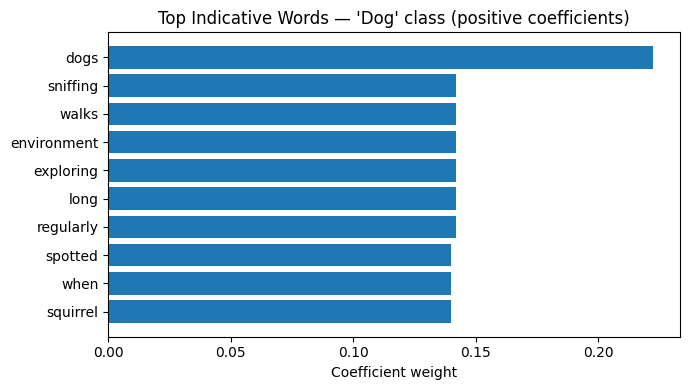

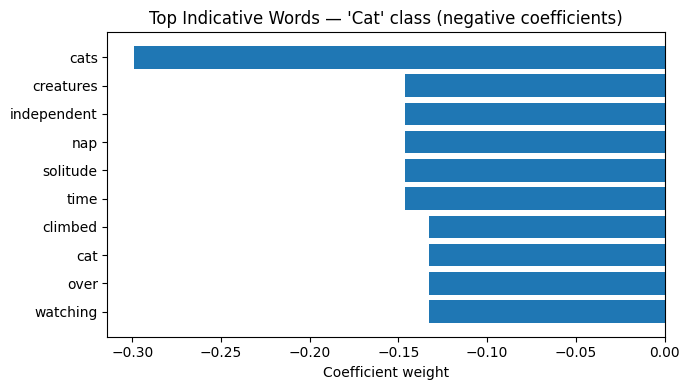

In [19]:
feature_names = vectorizer.get_feature_names_out()
coefs = model.coef_.ravel()  # shape: (n_features,)

top_n = 10

# Top words for 'Dog' (positive coefficients)
top_dog_idx = np.argsort(coefs)[-top_n:][::-1]
top_dog_words = [feature_names[i] for i in top_dog_idx]
top_dog_vals  = coefs[top_dog_idx]

plt.figure(figsize=(7, 4))
plt.barh(top_dog_words[::-1], top_dog_vals[::-1])
plt.title("Top Indicative Words — 'Dog' class (positive coefficients)")
plt.xlabel("Coefficient weight")
plt.tight_layout()
plt.show()

# Top words for 'Cat' (negative coefficients)
top_cat_idx = np.argsort(coefs)[:top_n]
top_cat_words = [feature_names[i] for i in top_cat_idx]
top_cat_vals  = coefs[top_cat_idx]

plt.figure(figsize=(7, 4))
plt.barh(top_cat_words[::-1], top_cat_vals[::-1])
plt.title("Top Indicative Words — 'Cat' class (negative coefficients)")
plt.xlabel("Coefficient weight")
plt.tight_layout()
plt.show()

**Visualize Logistic Regression decision boundary**

This visualization shows how the logistic regression model transforms the linear score `z` into a probability using the sigmoid function.

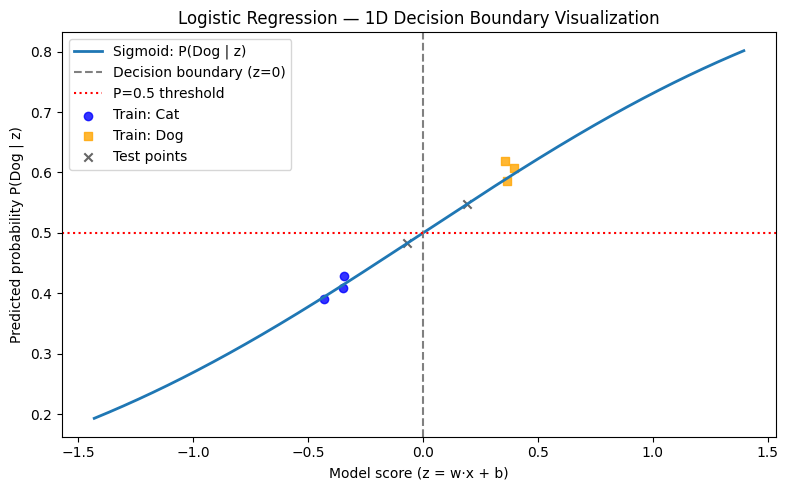

In [20]:
# Compute linear scores z = w·x + b for each sample
z_train = model.decision_function(X_train)
z_test = model.decision_function(X_test)

# Define sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Create a smooth curve for visualization
z_min = min(z_train.min(), z_test.min()) - 1.0
z_max = max(z_train.max(), z_test.max()) + 1.0
z_grid = np.linspace(z_min, z_max, 400)
p_grid = sigmoid(z_grid)

# Plot the sigmoid probability curve
plt.figure(figsize=(8, 5))
plt.plot(z_grid, p_grid, linewidth=2, label="Sigmoid: P(Dog | z)")

# Add decision boundary and probability threshold lines
plt.axvline(0.0, linestyle="--", color="gray", label="Decision boundary (z=0)")
plt.axhline(0.5, linestyle=":", color="red", label="P=0.5 threshold")

# Overlay training points by class (cats vs dogs)
y_train_arr = np.array(y_train)
rng = np.random.RandomState(42)
y_jitter = (rng.randn(len(y_train_arr)) * 0.02)  # small jitter for visibility

plt.scatter(
    z_train[y_train_arr == 0],
    sigmoid(z_train[y_train_arr == 0]) + y_jitter[y_train_arr == 0],
    color='blue', alpha=0.8, marker='o', label='Train: Cat'
)
plt.scatter(
    z_train[y_train_arr == 1],
    sigmoid(z_train[y_train_arr == 1]) + y_jitter[y_train_arr == 1],
    color='orange', alpha=0.8, marker='s', label='Train: Dog'
)

# Overlay test points
plt.scatter(z_test, sigmoid(z_test), color='black', alpha=0.6, marker='x', label='Test points')

plt.title("Logistic Regression — 1D Decision Boundary Visualization")
plt.xlabel("Model score (z = w·x + b)")
plt.ylabel("Predicted probability P(Dog | z)")
plt.legend()
plt.tight_layout()
plt.show()

**The plot above shows the smooth transition in probability near the boundary, illustrating that the model's decision is probabilistic, not hard-coded. Documents near `z=0` are more uncertain, while those farther away are classified with higher confidence.**

**Make predictions on the test set**

In [21]:
y_pred = model.predict( X_test )

**Calculate and print accuracy**

In [22]:
accuracy = accuracy_score(y_test , y_pred)
display(HTML(f"<p>Logistic Regression classifier <b>test</b> accuracy: <b>{accuracy :.2f}</b></p>"))

**Display test documents with predicted labels**

In [23]:
for doc, prediction in zip(docs_test, y_pred):
  label_name = "Cat" if prediction == 0 else "Dog"
  print (f'Predicted: "{label_name}" for document: "{doc}"')

Predicted: "Dog" for document: "Dogs bark loudly at strangers and fetch sticks with enthusiasm."
Predicted: "Cat" for document: "Cats meow softly and purr when content, loving to stretch in the sun."


**Make predictions with validation set**

In [24]:
y_val_pred = model.predict( X_val )
print(y_val_pred)

[0 0 0 0 0 0 1 0 1 0]


Most sentences were correctly predicted as 'cat' because the model successfully captured semantic patterns from training. Words and contexts expressing stillness, grace, or quiet motion align strongly with vocabulary learned from cat-related documents.

Even though the explicit word 'cat' never appears in validation sample, these terms trigger similar TF-IDF feature activations, leading to correct classification.

In [25]:
accuracy = accuracy_score (labels_val , y_val_pred )
display(HTML(f"<p>Logistic Regression classifier <b>validation</b> accuracy: <b>{accuracy :.2f}</b></p>"))

**Display validation documents with labels predicted by Logistic Regression classification model**

In [26]:
for doc, prediction in zip(docs_val, y_val_pred):
  label_name = "Cat" if prediction == 0 else "Dog"
  print (f'Predicted: "{label_name}" for document: "{doc}"')

Predicted: "Cat" for document: "He sits in the middle of the room, pretending to be asleep, and you think he’s meditating. But he’s really thinking of the best place to hide the sardine."
Predicted: "Cat" for document: "She stretched herself up on tiptoe and peeped over the edge of the mushroom."
Predicted: "Cat" for document: "The old man crouched down, clicked his tongue twice, and waited for the soft padding of paws."
Predicted: "Cat" for document: "The creature balanced on the fence top, tail flicking in slow, deliberate rhythm as dusk settled."
Predicted: "Cat" for document: "With a sudden leap, it vanished into the shadows, leaving the curtains swaying."
Predicted: "Cat" for document: "The small figure licked a paw and smoothed its face with practiced grace."
Predicted: "Dog" for document: "It circled twice before settling into the armchair, a picture of quiet possession."
Predicted: "Cat" for document: "A glint of moonlight caught its eyes, twin lanterns watching from the garden

**The validation results demonstrate that the Logistic Regression model can generalize meaningfully beyond explicit training words like 'cat' or 'dog', identifying cat-like descriptions based on associated vocabulary and style.**

**However, occasional misclassifications occur where sentences contain neutral or ambiguous motion verbs that resemble patterns seen in dog-related texts.
This highlights both the strength and the limitation of linear, word-based models in NLP: they capture strong correlations but cannot yet model full contextual semantics.**

## Naive Bayes Classifier

The [Naive Bayes](https://scikit-learn.org/stable/modules/naive_bayes.html) is a probabilistic classifier based on Bayes theorem, which predicts the most likely class for a given input based on probabilities learned from the training data. It is "naive" because it assumes that all features (in our case, words) are independent of each other. Although this assumption obviously is not true in language, but it works surprisingly well on practice.

**Train a Naive Bayes classifier**

**How Naive Bayes works in practice:**

  1. During training, the model learns:
     * How often each word appears in documents of each class
     * The overall frequency of each class

  2. During prediction, for a new document:
     * It multiplies (or adds in log form) the probabilities of each word given each class calculating `P(class | document)`
     * The class with the highest combined probability wins

For example, if "purr", "nap", and "mouse" often appear in "cat" documents, a new document containing these words will likely be classified as cat-related.

In [27]:
model_nb = MultinomialNB() # Each feature (word) is modeled as coming from a multinomial distribution conditioned on the class
model_nb.fit(X_train, y_train)

MultinomialNB()

**Print most important words per class from Naive Bayes classifier**

In [28]:
feature_names = vectorizer.get_feature_names_out()

# For each class (0 = cat, 1 = dog)
for i, class_label in enumerate(model_nb.classes_):
    top_indices = np.argsort(model_nb.feature_log_prob_[i])[::-1][:10]  # top 10 words
    top_words = [(feature_names[j], round(model_nb.feature_log_prob_[i][j], 3)) for j in top_indices]
    class_name = "Cat" if class_label == 0 else "Dog"
    print(f"\nTop words for class '{class_name}':")
    for word, weight in top_words:
        print(f"  {word:<15} {weight}")


Top words for class 'Cat':
  cats            -3.543
  the             -3.676
  and             -3.782
  nap             -3.797
  independent     -3.797
  time            -3.797
  solitude        -3.797
  creatures       -3.797
  purring         -3.821
  watching        -3.821

Top words for class 'Dog':
  dogs            -3.665
  and             -3.768
  walks           -3.804
  environment     -3.804
  long            -3.804
  sniffing        -3.804
  exploring       -3.804
  regularly       -3.804
  spotted         -3.809
  squirrel        -3.809


**Visual demostration how the Naive Bayes model "thinks" with top words**

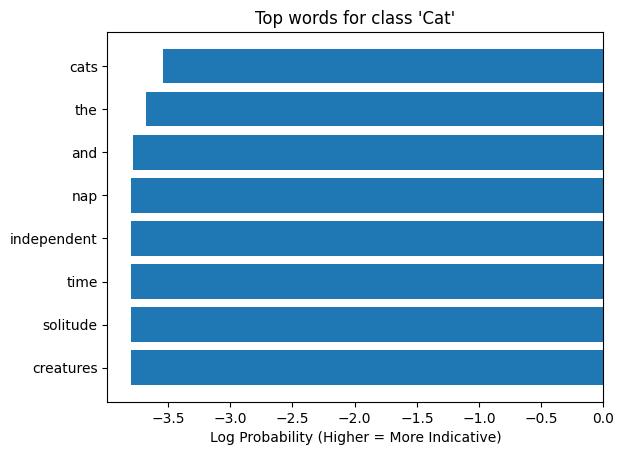

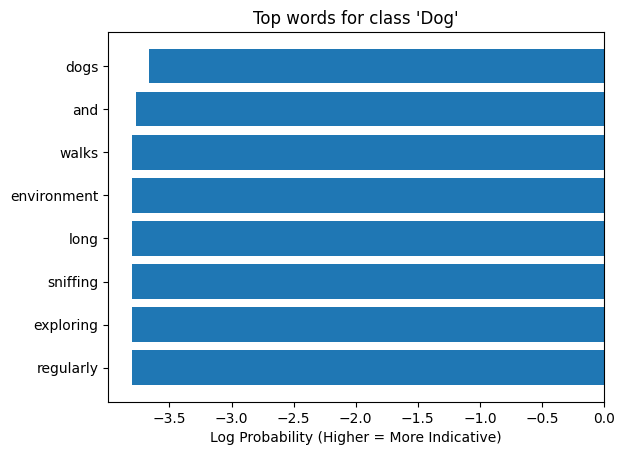

In [29]:
for i, class_label in enumerate(model_nb.classes_):
    top_indices = np.argsort(model_nb.feature_log_prob_[i])[::-1][:8]
    top_words = [feature_names[j] for j in top_indices]
    top_weights = model_nb.feature_log_prob_[i][top_indices]

    plt.figure()
    plt.barh(top_words[::-1], top_weights[::-1])
    class_name = "Cat" if class_label == 0 else "Dog"
    plt.title(f"Top words for class '{class_name}'")
    plt.xlabel("Log Probability (Higher = More Indicative)")
    plt.show()

**Make predictions on the test set**

In [30]:
y_pred = model_nb.predict(X_test)

**Calculate and print test accuracy**

In [31]:
accuracy = accuracy_score(y_test , y_pred)
display(HTML(f"<p>Naive Bayes classifier <b>test</b> accuracy: <b>{accuracy :.2f}</b></p>"))

**Display test documents with predicted labels**

In [32]:
for doc, prediction in zip(docs_test, y_pred):
  label_name = "Cat" if prediction == 0 else "Dog"
  print (f'Predicted: "{label_name}" for document: "{doc}"')

Predicted: "Dog" for document: "Dogs bark loudly at strangers and fetch sticks with enthusiasm."
Predicted: "Cat" for document: "Cats meow softly and purr when content, loving to stretch in the sun."


**Calculate and print predicted labels for validation set**

In [33]:
y_val_pred = model_nb.predict(X_val)
print(y_val_pred)

[0 0 0 0 0 0 1 0 1 0]


In [34]:
accuracy = accuracy_score(labels_val, y_val_pred)
display(HTML(f"<p>Naive Bayes classifier <b>validation</b> accuracy: <b>{accuracy :.2f}</b></p>"))

In [35]:
for doc, prediction in zip(docs_val, y_val_pred):
  label_name = "Cat" if prediction == 0 else "Dog"
  print (f'Predicted: "{label_name}" for document: "{doc}"')

Predicted: "Cat" for document: "He sits in the middle of the room, pretending to be asleep, and you think he’s meditating. But he’s really thinking of the best place to hide the sardine."
Predicted: "Cat" for document: "She stretched herself up on tiptoe and peeped over the edge of the mushroom."
Predicted: "Cat" for document: "The old man crouched down, clicked his tongue twice, and waited for the soft padding of paws."
Predicted: "Cat" for document: "The creature balanced on the fence top, tail flicking in slow, deliberate rhythm as dusk settled."
Predicted: "Cat" for document: "With a sudden leap, it vanished into the shadows, leaving the curtains swaying."
Predicted: "Cat" for document: "The small figure licked a paw and smoothed its face with practiced grace."
Predicted: "Dog" for document: "It circled twice before settling into the armchair, a picture of quiet possession."
Predicted: "Cat" for document: "A glint of moonlight caught its eyes, twin lanterns watching from the garden

**Why Naive Bayes is good for NLP?**

  * Simple and fast, it works well even on small datasets
  * Effective baseline for text classification problems (spam detection, sentiment analysis, etc.)
  * Handles high-dimensional sparse data (bag of words, TF-IDF) efficiently
  * It is interpretable, which means we can easily see which words are most important for each class.

## SVM - Support Vector Machine

[SVM](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) is a supervised learning algorithm that separates classes by finding the optimal boundary (or hyperplane in multidimensional case) between classes in feature space.

For text data (after TF-IDF vectorization), each document becomes a high-dimensional vector of word weights. Then the SVM learns a decision boundary that best separates the classes (in our cases cat-related vs dog-related documents) with the widest possible margin between the two.

**Initialize the SVM classifier**

In [36]:
model_svm = SVC(kernel = 'linear') # linear kernel - the separating boundary is a straight line

**Train the SVM classifier**

In [37]:
model_svm.fit(X_train, y_train)

SVC(kernel='linear')

**Interpretation of feature importance: top 10 words**

In [38]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model_svm.coef_.toarray().flatten()

# Top words per class
top_cat_idx = np.argsort(coefficients)[:10]
top_dog_idx = np.argsort(coefficients)[-10:]

print("Top words for 'Cat' class:")
print([feature_names[i] for i in top_cat_idx])

print("\nTop words for 'Dog' class:")
print([feature_names[i] for i in top_dog_idx])

Top words for 'Cat' class:
['cats', 'creatures', 'independent', 'nap', 'solitude', 'time', 'climbed', 'cat', 'over', 'watching']

Top words for 'Dog' class:
['squirrel', 'when', 'spotted', 'regularly', 'long', 'exploring', 'environment', 'walks', 'sniffing', 'dogs']


**Visual demostration how the SVM model "thinks" with top words**

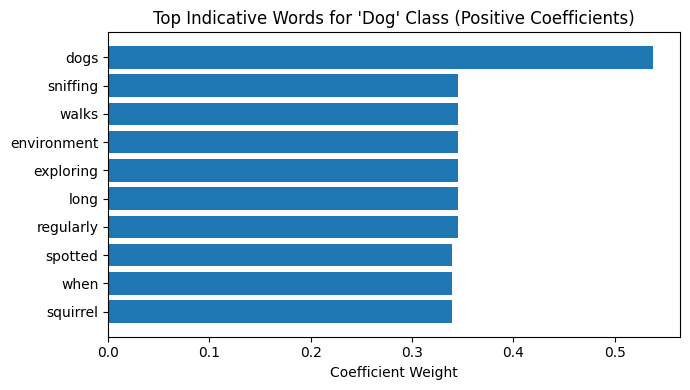

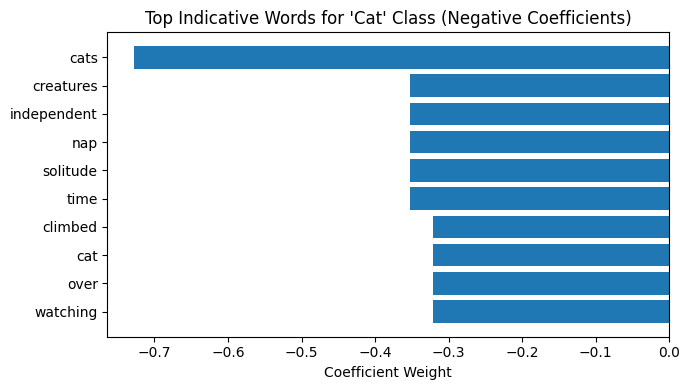

In [39]:
feature_names = vectorizer.get_feature_names_out()
coefs = model_svm.coef_.toarray().flatten()

top_k = 10

# Dog class (positive coefficients)
top_dog_idx = np.argsort(coefs)[-top_k:][::-1]
plt.figure(figsize=(7, 4))
plt.barh(
    [feature_names[i] for i in top_dog_idx][::-1],
    coefs[top_dog_idx][::-1]
)
plt.title("Top Indicative Words for 'Dog' Class (Positive Coefficients)")
plt.xlabel("Coefficient Weight")
plt.tight_layout()
plt.show()

# Cat class (negative coefficients)
top_cat_idx = np.argsort(coefs)[:top_k]
plt.figure(figsize=(7, 4))
plt.barh(
    [feature_names[i] for i in top_cat_idx][::-1],
    coefs[top_cat_idx][::-1]
)
plt.title("Top Indicative Words for 'Cat' Class (Negative Coefficients)")
plt.xlabel("Coefficient Weight")
plt.tight_layout()
plt.show()

**Visualize SVM decision boundary**

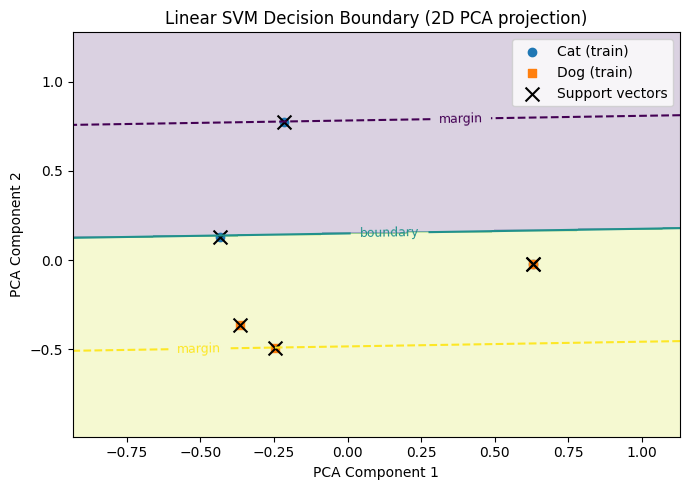

In [40]:
# Reduce TF-IDF features to 2D
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train.toarray())
X_test_2d = pca.transform(X_test.toarray())

# Train a new SVM on the 2D projection (for visualization only)
svm_2d = SVC(kernel='linear')
svm_2d.fit(X_train_2d, y_train)

# Create mesh grid to plot decision regions
x_min, x_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
y_min, y_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = svm_2d.decision_function(grid).reshape(xx.shape)

# Plot decision boundary, margin, and points
plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, (Z > 0).astype(int), alpha=0.2)
contours = plt.contour(xx, yy, Z, levels=[-1, 0, 1], linestyles=['--', '-', '--'])
plt.clabel(contours, fmt={0: 'boundary', -1: 'margin', 1: 'margin'}, inline=True, fontsize=9)

# Plot training points
y_train_arr = np.array(y_train)
plt.scatter(X_train_2d[y_train_arr == 0, 0], X_train_2d[y_train_arr == 0, 1], label="Cat (train)", marker='o')
plt.scatter(X_train_2d[y_train_arr == 1, 0], X_train_2d[y_train_arr == 1, 1], label="Dog (train)", marker='s')

# Highlight support vectors
sv = svm_2d.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], marker='x', s=100, color='black', label="Support vectors")

plt.title("Linear SVM Decision Boundary (2D PCA projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.tight_layout()
plt.show()

**Make predictions on the test set**

In [41]:
y_pred = model_svm.predict(X_test)

**Calculate and print test accuracy**

In [42]:
accuracy = accuracy_score(y_test , y_pred)
display(HTML(f"<p>SVM classifier <b>test</b> accuracy: <b>{accuracy :.2f}</b></p>"))

**Display test documents with predicted labels**

In [43]:
for doc, prediction in zip(docs_test, y_pred):
  label_name = "Cat" if prediction == 0 else "Dog"
  print (f'Predicted: "{label_name}" for document: "{doc}"')

Predicted: "Dog" for document: "Dogs bark loudly at strangers and fetch sticks with enthusiasm."
Predicted: "Cat" for document: "Cats meow softly and purr when content, loving to stretch in the sun."


**Validate SVM results**

In [44]:
y_val_pred = model_svm.predict(X_val)
print(y_val_pred)

[0 0 0 1 1 0 1 0 1 0]


In [45]:
accuracy = accuracy_score(labels_val, y_val_pred)
display(HTML(f"<p>SVM classifier <b>validation</b> accuracy: <b>{accuracy :.2f}</b></p>"))

In [46]:
for doc, prediction in zip(docs_val, y_val_pred):
  label_name = "Cat" if prediction == 0 else "Dog"
  print (f'Predicted: "{label_name}" for document: "{doc}"')

Predicted: "Cat" for document: "He sits in the middle of the room, pretending to be asleep, and you think he’s meditating. But he’s really thinking of the best place to hide the sardine."
Predicted: "Cat" for document: "She stretched herself up on tiptoe and peeped over the edge of the mushroom."
Predicted: "Cat" for document: "The old man crouched down, clicked his tongue twice, and waited for the soft padding of paws."
Predicted: "Dog" for document: "The creature balanced on the fence top, tail flicking in slow, deliberate rhythm as dusk settled."
Predicted: "Dog" for document: "With a sudden leap, it vanished into the shadows, leaving the curtains swaying."
Predicted: "Cat" for document: "The small figure licked a paw and smoothed its face with practiced grace."
Predicted: "Dog" for document: "It circled twice before settling into the armchair, a picture of quiet possession."
Predicted: "Cat" for document: "A glint of moonlight caught its eyes, twin lanterns watching from the garden